Шаблон для таблиц
<table name="Шаблон">
    <tr><th>Вопросы</th><th>Ответы</th></tr>
    <tr><td>Вопрос</td><td>Ответ</td></tr>
    <!-- tr - table row
    th - table header
    td - table data -->
</table>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [3]:
np.random.seed(42)
 
true_p = 0.7
n = 20
data = np.random.binomial(1, true_p, size=n)     # 20 испытаний Бернулли
 
print("Данные:", data)
 
k = np.sum(data)          # число успехов (подсказка: сумма единиц в data)
p_hat = k / n            # MLE-оценка по формуле из лекции
 
print(f"Число успехов k = {k} из n = {n}")
print(f"MLE-оценка: p_hat = {p_hat}")
print(f"Истинное значение (для сравнения): {true_p}")


Данные: [1 0 0 1 1 1 1 0 1 0 1 0 0 1 1 1 1 1 1 1]
Число успехов k = 14 из n = 20
MLE-оценка: p_hat = 0.7
Истинное значение (для сравнения): 0.7


<table name="Шаблон">
    <tr><th>Вопросы</th><th>Ответы</th></tr>
    <tr><td>Совпадает ли полученная MLE-оценка с истинным значением параметра в точности?<br>
     Если нет — это ошибка в коде или ожидаемый результат? Обоснуйте, опираясь на материал лекции.</td><td>Полностью совпадает</td></tr>
</table>

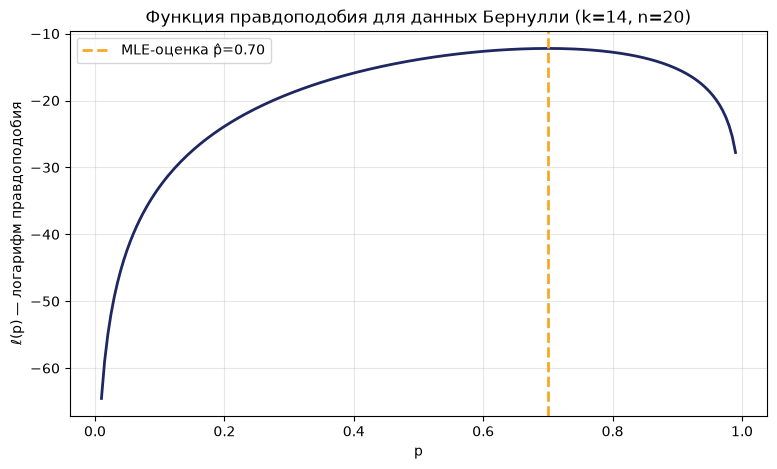

p, максимизирующее ℓ(p) численно: 0.699
MLE-оценка по формуле p̂=k/n: 0.700


In [4]:
def log_likelihood(p, k, n):
    return k * np.log(p) + (n - k) * np.log(1 - p)     # завершите формулу

p_values = np.linspace(0.01, 0.99, 200)
log_L_values = log_likelihood(p_values, k, n)
 
plt.figure(figsize=(9, 5))
plt.plot(p_values, log_L_values, color='#1E2761', linewidth=2)
plt.axvline(x=p_hat, color='#F9A826', linestyle='--', linewidth=2, label=f'MLE-оценка p̂={p_hat:.2f}')
plt.xlabel('p')
plt.ylabel('ℓ(p) — логарифм правдоподобия')
plt.title(f'Функция правдоподобия для данных Бернулли (k={k}, n={n})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
 
# Численная проверка: находим p, при котором log_L_values максимально
p_at_max = p_values[np.argmax(log_L_values)]
print(f"p, максимизирующее ℓ(p) численно: {p_at_max:.3f}")
print(f"MLE-оценка по формуле p̂=k/n: {p_hat:.3f}")


Шаблон для таблиц
<table name="Шаблон">
    <tr><th>Вопросы</th><th>Ответы</th></tr>
    <tr><td>Совпадает ли положение оранжевой пунктирной линии (p̂, вычисленное по формуле) с визуальным максимумом синей кривой на графике? Совпадает ли p_at_max, найденное численным перебором, с p_hat, вычисленным по формуле?</td><td>Да, всё совпадает</td></tr>
    <!-- tr - table row
    th - table header
    td - table data -->
</table>

In [9]:
response_times = np.array([195, 205, 198, 210, 190, 200, 207, 193, 202, 200])
n = len(response_times)
 
mu_hat = np.mean(response_times)                       # MLE-оценка среднего
 
var_mle = np.var(response_times, ddof=0)             # MLE (смещённая): деление на n
var_unbiased = np.var(response_times, ddof=1)        # несмещённая: деление на (n-1)
 
print(f"MLE-оценка среднего:      μ̂ = {mu_hat:.4f}")
print(f"MLE-оценка дисперсии:     σ̂² = {var_mle:.4f}  (деление на n)")
print(f"Несмещённая дисперсия:    s² = {var_unbiased:.4f}  (деление на n-1)")
 
# Проверка с помощью scipy.stats.norm.fit() -- тоже вычисляет MLE!
mu_fit, sigma_fit = norm.fit(response_times)
print(f"\nПроверка через scipy.stats.norm.fit(): μ={mu_fit:.4f}, σ={sigma_fit:.4f}")
print(f"σ² из scipy: {sigma_fit**2:.4f}  (должно совпасть с MLE-оценкой σ̂² выше)")


MLE-оценка среднего:      μ̂ = 200.0000
MLE-оценка дисперсии:     σ̂² = 35.6000  (деление на n)
Несмещённая дисперсия:    s² = 39.5556  (деление на n-1)

Проверка через scipy.stats.norm.fit(): μ=200.0000, σ=5.9666
σ² из scipy: 35.6000  (должно совпасть с MLE-оценкой σ̂² выше)


Шаблон для таблиц
<table name="Шаблон">
    <tr><th>Вопросы</th><th>Ответы</th></tr>
    <tr><td>Какая из двух оценок дисперсии (MLE или несмещённая) оказалась больше? <br>
    Согласуется ли это с тем, что говорилось на лекции о систематическом занижении MLE-оценки?<br>
     С каким из двух значений (var_mle или var_unbiased) совпал результат scipy.stats.norm.fit()?</td><td>Ответ</td></tr>
    <!-- tr - table row
    th - table header
    td - table data -->
</table>

n=10: p̂=0.6000, ошибка=0.1000
n=50: p̂=0.7600, ошибка=0.0600
n=200: p̂=0.6950, ошибка=0.0050
n=1000: p̂=0.6980, ошибка=0.0020
n=10000: p̂=0.7094, ошибка=0.0094


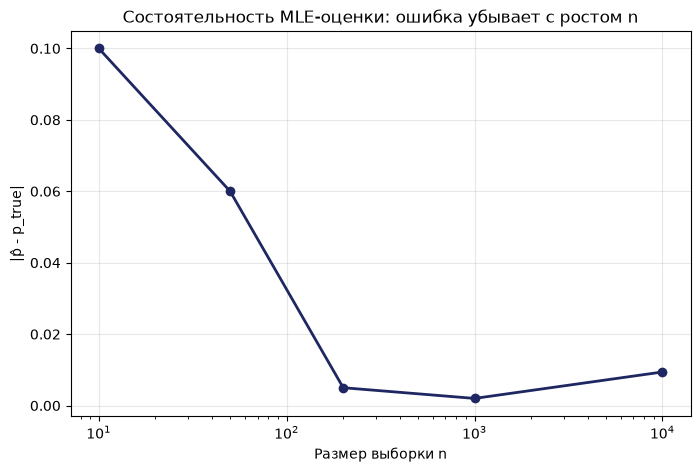

In [12]:
np.random.seed(42)
 
true_p = 0.7
sample_sizes = [10, 50, 200, 1000, 10000]
errors = []
 
for n in sample_sizes:
    data = np.random.binomial(1, true_p, size=n)
    p_hat_n = np.mean(data)
    error = abs(p_hat_n - true_p)          # вычислите абсолютную ошибку
    errors.append(error)
    print(f"n={n}: p̂={p_hat_n:.4f}, ошибка={error:.4f}")
 
plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, errors, marker='o', color='#1E2761', linewidth=2)
plt.xscale('log')                        # какую шкалу мы использовали для оси x в Практике 1?
plt.xlabel('Размер выборки n')
plt.ylabel('|p̂ - p_true|')
plt.title('Состоятельность MLE-оценки: ошибка убывает с ростом n')
plt.grid(True, alpha=0.3)
plt.show()
